# Supporting Notebook for the "Introduction to Bayesian Networks" post

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chisquare
import pandas as pd
import os

## Demonstration of Independence of Age and Blood Type

In [4]:
outdir = "../../src/assets/images/2025-03-31/"
# Make this directory if it doesn't exist
if not os.path.exists(outdir):
    os.makedirs(outdir)

In [10]:
# Set matplotlib font to Helvetica
plt.rcParams['font.family'] = 'Helvetica'

In [18]:
# Read the healtcare data
hldata = pd.read_csv('healthcare_dataset.csv')
blood_groups = hldata['Blood Type'].unique()

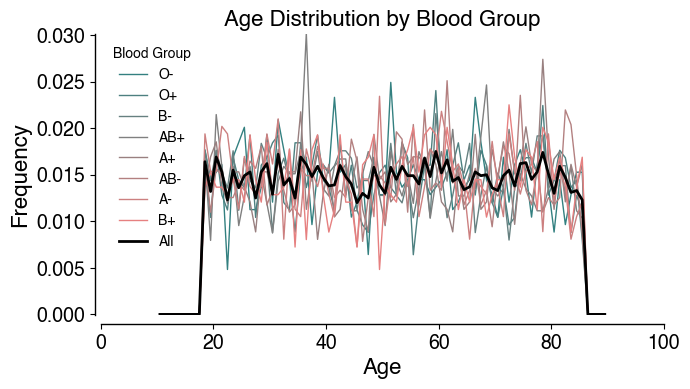

In [111]:
# Plot the histograms of Age for different Blood Groups
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)
for i, blood_group in enumerate(blood_groups):
    ages = hldata[hldata['Blood Type'] == blood_group]['Age']
    vals, bins = np.histogram(ages, bins=80, range=(10, 90), density=True)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    color = [0.2 + 0.1 * i, 0.5, 0.5]
    ax.plot(bin_centers, vals, label=blood_group, lw=1, color=color)
vals, bins = np.histogram(hldata['Age'], bins=80, range=(10, 90), density=True)
ax.plot(bin_centers, vals, lw=2, color="k", label="All")
ax.set_xlim(0, 100)
ax.set_ylim(-0.0001, 0.0301)
ax.legend(title='Blood Group', loc=2, frameon=False, ncols=1, fontsize=10)
ax.set_xlabel('Age', fontsize=16)
ax.set_ylabel('Frequency', fontsize=16)
ax.set_title('Age Distribution by Blood Group', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_position(('data', -1))
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('data', -0.001))
# Set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
# Save the figure
plt.savefig(f'{outdir}/age-bloodtype.svg', bbox_inches='tight', format='svg')

In [150]:
chi2_results = {}

# Expected counts
counts_expected, _ = np.histogram(hldata['Age'], bins=80, range=(10, 90), density=False)
counts_expected = counts_expected + 1e-12

# Get the conditional counts
for bg in blood_groups:
    counts_cond, _ = np.histogram(hldata[hldata['Blood Type'] == bg]['Age'], bins=80, range=(10, 90), density=False)
    counts_cond = counts_cond + 1e-12
    
    # Scale the counts_cond to the expected counts
    counts_scaled = counts_expected * np.sum(counts_cond) / np.sum(counts_expected)

    # Calculate the Chi2 statistic
    chi2_stat, p_val = chisquare(f_obs=counts_cond, f_exp=counts_scaled)
    chi2_results[bg] = (chi2_stat, p_val)

# Print the results
print("Chi-squared test results:")
for bg, (chi2_stat, p_value) in chi2_results.items():
    print(f"Blood Group {bg}: Chi-squared statistic = {chi2_stat:.4f}, p-value = {p_value:.4f}")

Chi-squared test results:
Blood Group O-: Chi-squared statistic = 60.0555, p-value = 0.9445
Blood Group O+: Chi-squared statistic = 44.4460, p-value = 0.9994
Blood Group B-: Chi-squared statistic = 34.5577, p-value = 1.0000
Blood Group AB+: Chi-squared statistic = 62.5744, p-value = 0.9125
Blood Group A+: Chi-squared statistic = 52.9566, p-value = 0.9893
Blood Group AB-: Chi-squared statistic = 58.5873, p-value = 0.9587
Blood Group A-: Chi-squared statistic = 63.9070, p-value = 0.8912
Blood Group B+: Chi-squared statistic = 60.7175, p-value = 0.9371


### Relationship between Two Gaussian random variables 

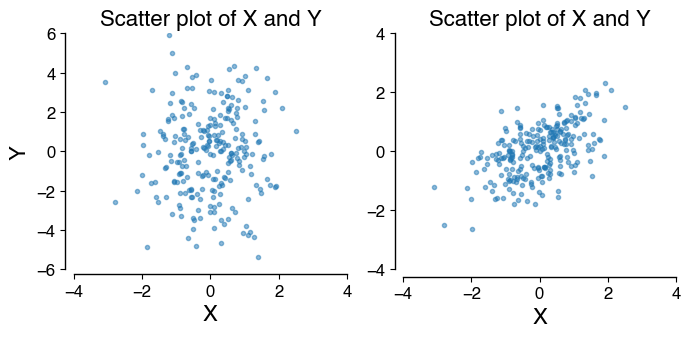

In [46]:
N = 250
x = np.random.randn(N)
y1 = 2 * np.random.randn(N)
y2 = 0.5 * x + 0.7 * np.random.randn(N)

fig = plt.figure(figsize=(7, 3.5))
ax = fig.add_subplot(121)
ax.scatter(x, y1, marker='.', alpha=0.5)
ax.set_xlim(-4, 4)
ax.set_ylim(-6, 6)
ax.set_xlabel('X', fontsize=16)
ax.set_ylabel('Y', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_title('Scatter plot of X and Y', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_position(('data', -4.25))
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('data', -6.25))
ax = fig.add_subplot(122)
ax.scatter(x, y2, marker='.', alpha=0.5)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel('X', fontsize=16)
# ax.set_ylabel('Y', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_title('Scatter plot of X and Y', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['left'].set_position(('data', -4.25))
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('data', -4.25))
plt.tight_layout()
# Save the figure
plt.savefig(f'{outdir}/gaussrandvar.svg', bbox_inches='tight', format='svg')

## Conditional 

In [127]:
N = 10000
# Disease prevalence
pdis = 0.1
dis = np.random.rand(N) < pdis
# Test sensitivity
ptpr = 0.9
pfpr = 0.05

# Diagnostic test (lambda function)
diag_test = lambda d: 1.0 * (np.random.rand() < ptpr if d == 1 else np.random.rand() < pfpr)

# Go through each patient and generate the test results for the two tests.
data = pd.DataFrame(columns=['Disease', 'Test1', 'Test2'])
data['Disease'] = dis
data['Test1'] = [diag_test(d) for d in dis]
data['Test2'] = [diag_test(d) for d in dis]

In [186]:
dir(plt.cm)

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r',
 'CMRmap',
 'CMRmap_r',
 'ColormapRegistry',
 'Dark2',
 'Dark2_r',
 'GnBu',
 'GnBu_r',
 'Grays',
 'Greens',
 'Greens_r',
 'Greys',
 'Greys_r',
 'Mapping',
 'OrRd',
 'OrRd_r',
 'Oranges',
 'Oranges_r',
 'PRGn',
 'PRGn_r',
 'Paired',
 'Paired_r',
 'Pastel1',
 'Pastel1_r',
 'Pastel2',
 'Pastel2_r',
 'PiYG',
 'PiYG_r',
 'PuBu',
 'PuBuGn',
 'PuBuGn_r',
 'PuBu_r',
 'PuOr',
 'PuOr_r',
 'PuRd',
 'PuRd_r',
 'Purples',
 'Purples_r',
 'RdBu',
 'RdBu_r',
 'RdGy',
 'RdGy_r',
 'RdPu',
 'RdPu_r',
 'RdYlBu',
 'RdYlBu_r',
 'RdYlGn',
 'RdYlGn_r',
 'Reds',
 'Reds_r',
 'ScalarMappable',
 'Set1',
 'Set1_r',
 'Set2',
 'Set2_r',
 'Set3',
 'Set3_r',
 'Spectral',
 'Spectral_r',
 'Wistia',
 'Wistia_r',
 'YlGn',
 'YlGnBu',
 'YlGnBu_r',
 'YlGn_r',
 'YlOrBr',
 'YlOrBr_r',
 'YlOrRd',
 'YlOrRd_r',
 '_LUTSIZE',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '

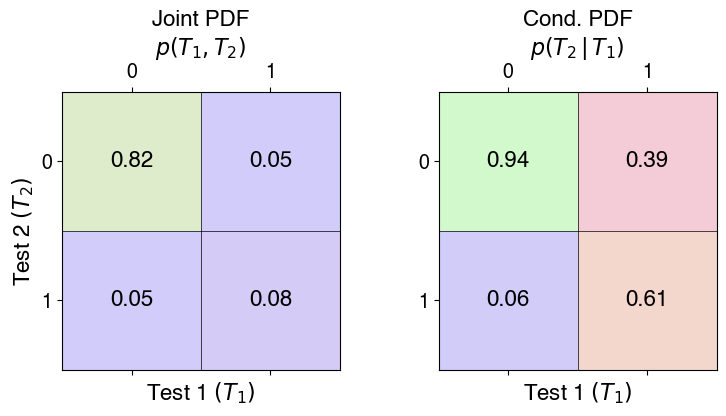

In [203]:
# Plot the confusion matrix
fig = plt.figure(figsize=(8, 4))
confmat = pd.crosstab(data['Test1'], data['Test2'],
                      rownames=['Test1'], colnames=['Test2'])
confmat = confmat.values
confmat = confmat.astype(float)
# confmat_joint = confmat / np.sum(confmat, axis=0)[np.newaxis, :]
confmat_joint = confmat / np.sum(confmat)
# Joint probability distribution
ax = fig.add_subplot(121)
cax = ax.matshow(confmat_joint, cmap=plt.cm.brg, vmin=0, vmax=1, alpha=0.2)
for (i, j), val in np.ndenumerate(confmat_joint):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=16)
# Draw border between cells
ax.axhline(0.5, lw=0.5, color='black')
ax.axvline(0.5, lw=0.5, color='black')
# Set the ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])
# Set the title and labels
ax.set_title('Joint PDF\n$p(T_1, T_2)$', fontsize=16)
ax.set_xlabel('Test 1 $(T_1)$', fontsize=16)
ax.set_ylabel('Test 2 $(T_2)$', fontsize=16)
# Set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=14)

# Conditional distribution Test2 | Test1
confmat_cond = confmat / np.sum(confmat, axis=0)[np.newaxis, :]
ax = fig.add_subplot(122)
cax = ax.matshow(confmat_cond, cmap=plt.cm.brg, vmin=0, vmax=1, alpha=0.2)
for (i, j), val in np.ndenumerate(confmat_cond):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=16)
# Draw border between cells
ax.axhline(0.5, lw=0.5, color='black')
ax.axvline(0.5, lw=0.5, color='black')
# Set the ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])
# Set the title and labels
ax.set_title('Cond. PDF\n$p(T_2 \\, \\vert \\, T_1)$', fontsize=16)
ax.set_xlabel('Test 1 $(T_1)$', fontsize=16)
# ax.set_ylabel('Test 2', fontsize=16)
# Set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
# Save the figure
plt.savefig(f'{outdir}/testretestcm1.svg', bbox_inches='tight', format='svg')

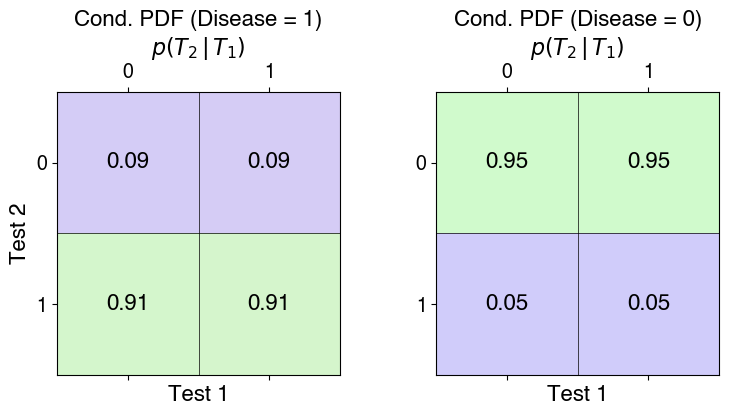

In [201]:
# Let's now condition on the known disease status
# Diease = 1
dis1 = data[data['Disease'] == 1]
dis0 = data[data['Disease'] == 0]
cm1 = pd.crosstab(dis1['Test1'], dis1['Test2'],
                  rownames=['Test1'], colnames=['Test2'])
cm1 = cm1.values
cm1 = cm1.astype(float)
cm1 = cm1 / np.sum(cm1, axis=0)[np.newaxis, :]
# cm1 = cm1 / np.sum(cm1)
# Plot the confusion matrix. Display the values in the matrix
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121)
cax = ax.matshow(cm1, cmap=plt.cm.brg, vmin=0, vmax=1, alpha=0.2)
for (i, j), val in np.ndenumerate(cm1):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=16)
# Draw border between cells
ax.axhline(0.5, lw=0.5, color='black')
ax.axvline(0.5, lw=0.5, color='black')
# Set the ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])
# Set the title and labels
ax.set_title('Cond. PDF (Disease = 1)\n$p(T_2 \\, \\vert \\, T_1)$', fontsize=16)
ax.set_xlabel('Test 1', fontsize=16)
ax.set_ylabel('Test 2', fontsize=16)
# Add color bar
# plt.colorbar(cax)
# Set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=14)
# Disease = 0

cm0 = pd.crosstab(dis0['Test1'], dis0['Test2'],
                  rownames=['Test1'], colnames=['Test2'])
cm0 = cm0.values
cm0 = cm0.astype(float)
cm0 = cm0 / np.sum(cm0, axis=0)[np.newaxis, :]
ax = fig.add_subplot(122)
cax = ax.matshow(cm0, cmap=plt.cm.brg, vmin=0, vmax=1, alpha=0.2)
for (i, j), val in np.ndenumerate(cm0):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=16)
# Draw border between cells
ax.axhline(0.5, lw=0.5, color='black')
ax.axvline(0.5, lw=0.5, color='black')
# Set the ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])
# Set the title and labels
ax.set_title('Cond. PDF (Disease = 0)\n$p(T_2 \\, \\vert \\, T_1)$', fontsize=16)
ax.set_xlabel('Test 1', fontsize=16)
# Add color bar
# plt.colorbar(cax)
# Set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
# Save the figure
plt.savefig(f'{outdir}/testretestcm2.svg', bbox_inches='tight', format='svg')

### Simulation on BN6

In [207]:
def gnoise(N, m, std):
    return np.random.randn(N) * std + m

In [ ]:
data = pd.DataFrame(columns=['X1', 'X2', 'X3', 'X4', 'X5'])
N = 10000
data['X1'] = gnoise(N, 0, np.sqrt(3))
data['X2'] = 2 * data['X1'] + gnoise(N, 0, 1)
data['X3'] = - data['X1'] + gnoise(N, 0, np.sqrt(2))
data['X4'] = 0.5 * data['X2'] - 0.5 * data['X3'] + gnoise(N, 0, 0)
data['X5'] = 3 * data['X4'] + gnoise(N, 0, 1)

In [243]:
import seaborn as sns

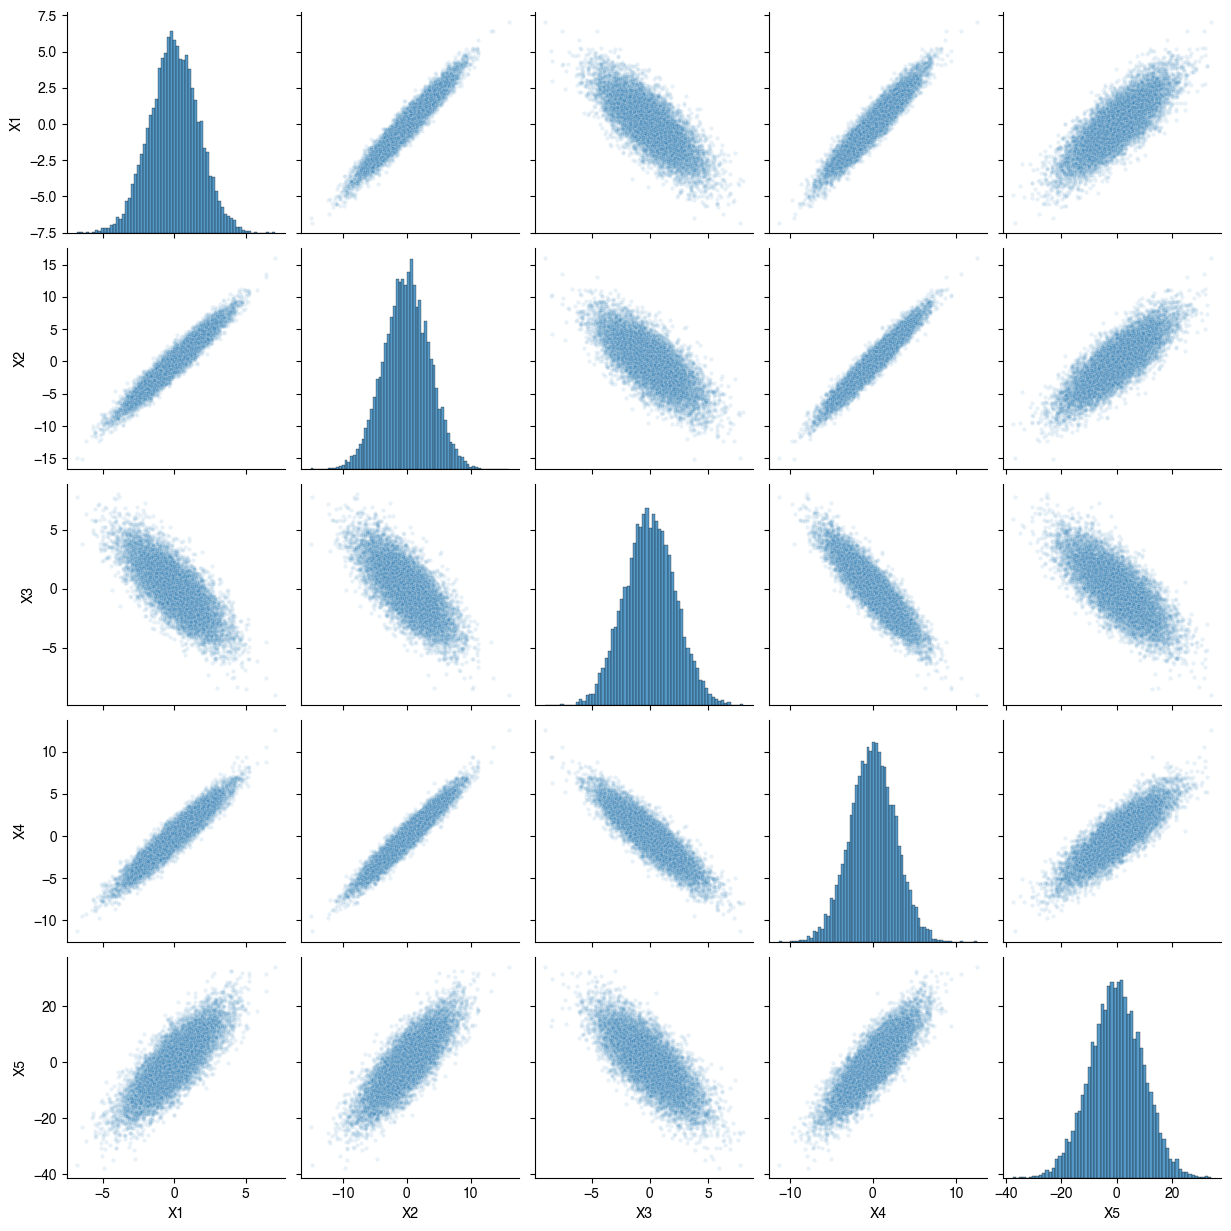

In [248]:
# Pairwise plot of data
sns.pairplot(data, diag_kind='hist', markers='.', plot_kws={'alpha': 0.1})

16


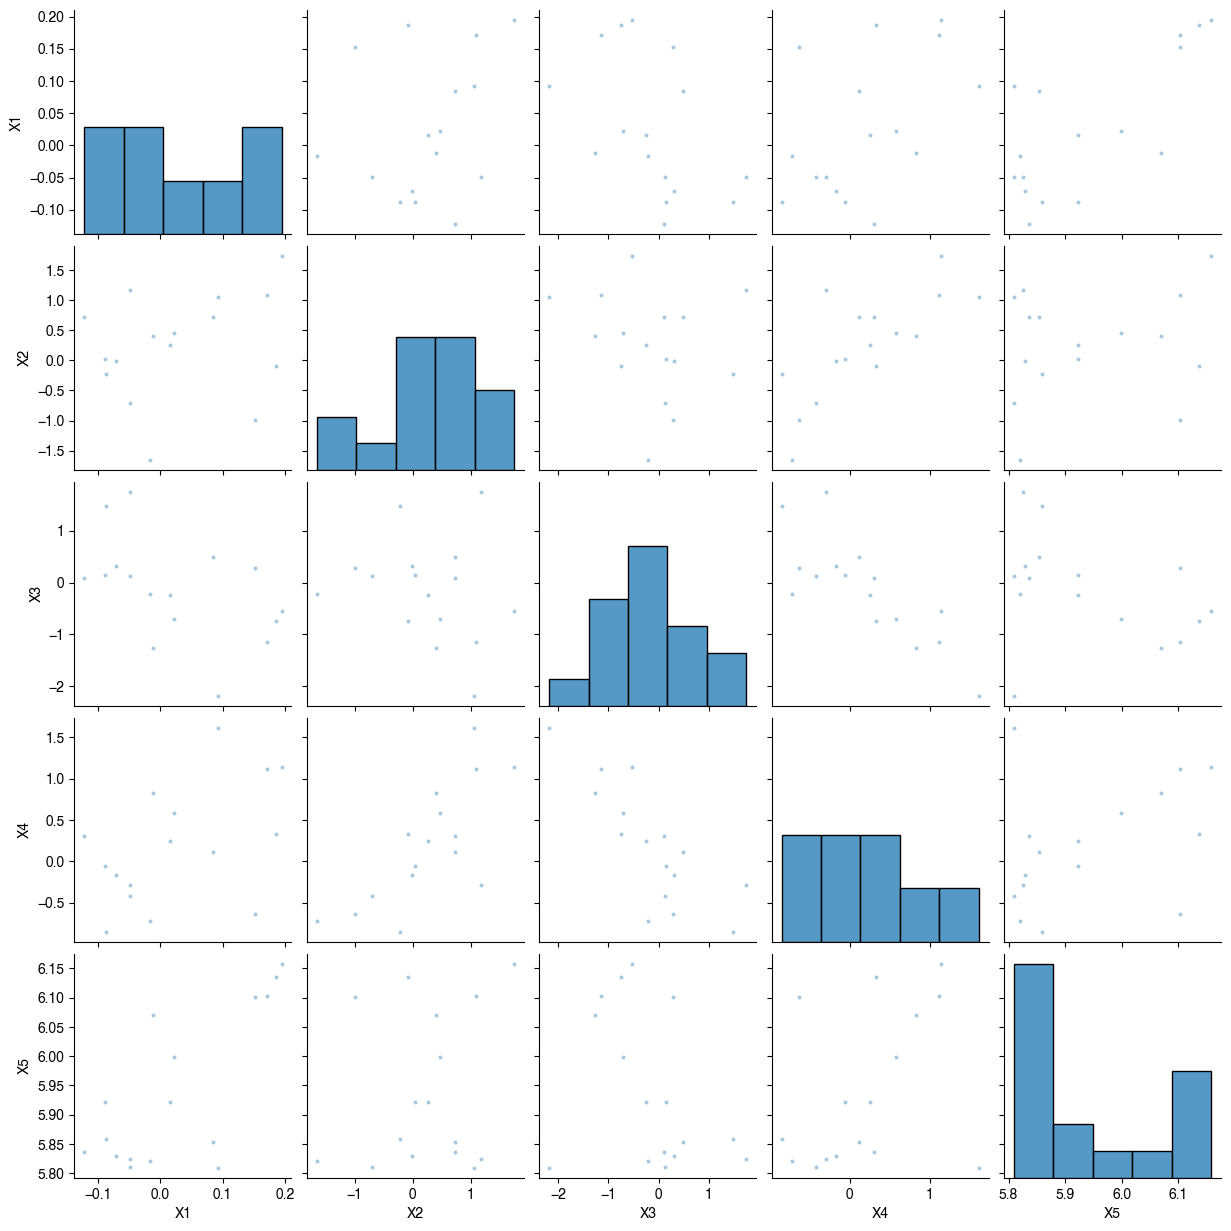

In [249]:
x1cond = 0.
# x4cond = 2.0
x5cond = 6.0
eps = 0.2

inx1 = np.abs(data['X1'] - x1cond) < eps
# inx4 = np.abs(data['X4'] - x4cond) < eps
inx5 = np.abs(data['X5'] - x5cond) < eps
print(np.sum(inx1 & inx5))
data_cond = data[inx1 & inx5]

# Pairwise plot of data
sns.pairplot(data_cond, diag_kind='hist', markers='.', plot_kws={'alpha': 0.4})